In [18]:
import pandas as pd

import matplotlib.pyplot as plt
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score

import seaborn as sns
from sklearn.preprocessing import StandardScaler, RobustScaler


from sklearn.naive_bayes import MultinomialNB
from sklearn.preprocessing import StandardScaler
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.decomposition import PCA
from sklearn.preprocessing import LabelEncoder

In [19]:
url = "https://raw.githubusercontent.com/krishna-koly/IMDB_TOP_1000/refs/heads/main/imdb_top_1000.csv"
df = pd.read_csv(url)


copy_of_df = df.copy()



In [20]:
df.head(20)

,Poster_Link,Series_Title,Released_Year,Certificate,Runtime,Genre,IMDB_Rating,Overview,Meta_score,Director,Star1,Star2,Star3,Star4,No_of_Votes,Gross
0,https://m.media-amazon.com/images/M/MV5BMDFkYT...,The Shawshank Redemption,1994,A,142 min,Drama,9.3,Two imprisoned men bond over a number of years...,80.0,Frank Darabont,Tim Robbins,Morgan Freeman,Bob Gunton,William Sadler,2343110,"28,341,469"
1,https://m.media-amazon.com/images/M/MV5BM2MyNj...,The Godfather,1972,A,175 min,"Crime, Drama",9.2,An organized crime dynasty's aging patriarch t...,100.0,Francis Ford Coppola,Marlon Brando,Al Pacino,James Caan,Diane Keaton,1620367,"134,966,411"
2,https://m.media-amazon.com/images/M/MV5BMTMxNT...,The Dark Knight,2008,UA,152 min,"Action, Crime, Drama",9.0,When the menace known as the Joker wreaks havo...,84.0,Christopher Nolan,Christian Bale,Heath Ledger,Aaron Eckhart,Michael Caine,2303232,"534,858,444"
3,https://m.media-amazon.com/images/M/MV5BMWMwMG...,The Godfather: Part II,1974,A,202 min,"Crime, Drama",9.0,The early life and career of Vito Corleone in ...,90.0,Francis Ford Coppola,Al Pacino,Robert De Niro,Robert Duvall,Diane Keaton,1129952,"57,300,000"
4,https://m.media-amazon.com/images/M/MV5BMWU4N2...,12 Angry Men,1957,U,96 min,"Crime, Drama",9.0,A jury holdout attempts to prevent a miscarria...,96.0,Sidney Lumet,Henry Fonda,Lee J. Cobb,Martin Balsam,John Fiedler,689845,"4,360,000"
5,https://m.media-amazon.com/images/M/MV5BNzA5ZD...,The Lord of the Rings: The Return of the King,2003,U,201 min,"Action, Adventure, Drama",8.9,Gandalf and Aragorn lead the World of Men agai...,94.0,Peter Jackson,Elijah Wood,Viggo Mortensen,Ian McKellen,Orlando Bloom,1642758,"377,845,905"
6,https://m.media-amazon.com/images/M/MV5BNGNhMD...,Pulp Fiction,1994,A,154 min,"Crime, Drama",8.9,"The lives of two mob hitmen, a boxer, a gangst...",94.0,Quentin Tarantino,John Travolta,Uma Thurman,Samuel L. Jackson,Bruce Willis,1826188,"107,928,762"
7,https://m.media-amazon.com/images/M/MV5BNDE4OT...,Schindler's List,1993,A,195 min,"Biography, Drama, History",8.9,"In German-occupied Poland during World War II,...",94.0,Steven Spielberg,Liam Neeson,Ralph Fiennes,Ben Kingsley,Caroline Goodall,1213505,"96,898,818"
8,https://m.media-amazon.com/images/M/MV5BMjAxMz...,Inception,2010,UA,148 min,"Action, Adventure, Sci-Fi",8.8,A thief who steals corporate secrets through t...,74.0,Christopher Nolan,Leonardo DiCaprio,Joseph Gordon-Levitt,Elliot Page,Ken Watanabe,2067042,"292,576,195"
9,https://m.media-amazon.com/images/M/MV5BMmEzNT...,Fight Club,1999,A,139 min,Drama,8.8,An insomniac office worker and a devil-may-car...,66.0,David Fincher,Brad Pitt,Edward Norton,Meat Loaf,Zach Grenier,1854740,"37,030,102"


In [21]:
# See directors that have certicate null, meta score null in order to see how we approach missing data
directors_with_nulls = df[df['Certificate'].isnull()]['Director'].unique()

filtered_df = df[df['Director'].isin(directors_with_nulls)]


stats = filtered_df.groupby('Director').agg(
    Total_Movies=('Director', 'count'),
    Null_Certificates=('Certificate', lambda x: x.isnull().sum())
)

for director, row in stats.iterrows():
    print(f"Director: {director}")
    print(f" - Total movies: {row['Total_Movies']}")
    print(f" - Movies without certificate: {row['Null_Certificates']}")
    print("-" * 30)


directors_with_nulls = df[df['Meta_score'].isnull()]['Director'].unique()

filtered_df = df[df['Director'].isin(directors_with_nulls)]

stats = filtered_df.groupby('Director').agg(
    Total_Movies=('Director', 'count'),
    Null_MetaScore=('Meta_score', lambda x: x.isnull().sum())
)

for director, row in stats.iterrows():
    print(f"Director: {director}")
    print(f" - Total movies: {row['Total_Movies']}")
    print(f" - Movies without Meta_score: {row['Null_MetaScore']}")
    print("-" * 30)

Director: agan Irmak
 - Total movies: 1
 - Movies without certificate: 1
------------------------------
Director: mer Faruk Sorak
 - Total movies: 1
 - Movies without certificate: 1
------------------------------
Director: Adam Elliot
 - Total movies: 1
 - Movies without certificate: 1
------------------------------
Director: Akira Kurosawa
 - Total movies: 10
 - Movies without certificate: 6
------------------------------
Director: Alain Resnais
 - Total movies: 1
 - Movies without certificate: 1
------------------------------
Director: Alexander Mackendrick
 - Total movies: 2
 - Movies without certificate: 1
------------------------------
Director: Alfred Hitchcock
 - Total movies: 14
 - Movies without certificate: 3
------------------------------
Director: Andrei Tarkovsky
 - Total movies: 5
 - Movies without certificate: 1
------------------------------
Director: Andrey Zvyagintsev
 - Total movies: 3
 - Movies without certificate: 1
------------------------------
Director: Billy 

Due to the fact that we have many directors that have only one entry in the top 100 imbd and we have data that are labeled in the same category like 12 angry man and pulp fiction witch both have the same genre but are categorized in different categories we can't use the category as a way to clasify the movie so we have to approach from a probabilistic standpoint for this we will use TF -Idf and Naive Bayes which are statistical models the

The tf score computes how frequent a word is in a document while the idf score computes how uncommon a word is in all documents as uncommon words can be used to identify words that are specific to a document only


MultiNomial Naive bayes does the following if we have a word (x and a category t) then we first compute the probability of a category happening

Then we compute the posterior probability P(word|category) by summing the score of every word in that category and normalizing by dividing it to the sum off all words in that category

after we computed the probability of word| category we
use Bayes Theorhem P(C|X) = P(x|c) * P(c) / P(x) as P(x) is the same for
all entries we can ignore it to simplify computations.

Because x is a vector of features we have P(x1|c)*P(x2|c)*...P(xn|C) but
because we are not interested in saying that if there are 3 x1 we use its tf idf score because it scales the word importance better


In [22]:
# Train data for categories using Naive Bayes

categories  = df['Certificate'].dropna().unique()

if df['Certificate'].isnull().sum() > 0:
  print(f"Missing certificates: {df['Certificate'].isnull().sum()}")
  movies_description_and_category = df[['Certificate','Overview']]

  movies_training = movies_description_and_category[movies_description_and_category['Certificate'].notnull()]

  movies_to_predict = movies_description_and_category[movies_description_and_category['Certificate'].isnull()]


  movie_training_descriptions = movies_training['Overview'].unique()

  tf_idf = TfidfVectorizer(stop_words='english')

  X_train_tfidf = tf_idf.fit_transform(movie_training_descriptions)

  nb_model = MultinomialNB()
  nb_model.fit(X_train_tfidf, movies_training['Certificate'])

  x_test = tf_idf.transform(movies_to_predict['Overview'])

  predicted_categories = nb_model.predict(x_test)

  df.loc[df['Certificate'].isnull(), 'Certificate'] = predicted_categories

  print(f"Missing certificates now: {df['Certificate'].isnull().sum()}")




Missing certificates: 101
Missing certificates now: 0


Get rid of collumns that have few entries as they populate the table with entries that in general will be 0 which can make the model to overfit

In [23]:
# Remove entries from genres that are rare and merge them


multi_label_encoding = 1
one_shot_encoding = 0


if multi_label_encoding:
    genre_encoded = df['Genre'].str.get_dummies(sep=', ')

    threshold = 50
    genre_sums = genre_encoded.sum()
    common_cols = genre_sums[genre_sums > threshold].index
    rare_cols = genre_sums[genre_sums <= threshold].index

    if len(rare_cols) > 0:
        genre_encoded['Other_Genre'] = genre_encoded[rare_cols].max(axis=1)
    else:
        genre_encoded['Other_Genre'] = 0

    genre_final = genre_encoded[list(common_cols) + ['Other_Genre']]
    df = df.drop('Genre', axis=1).join(genre_final)

if one_shot_encoding:
    df = pd.get_dummies(df, columns=['Certificate'], prefix='Cert', drop_first=True)


In [24]:
#Data cleaning scale data in order to train metascore
df['Runtime'] = df['Runtime'].astype(str).str.extract('(\d+)').astype(float)
df['Runtime'] = df['Runtime'].fillna(df['Runtime'].median())

r_scaler = StandardScaler()

df['scaled_votes'] = r_scaler.fit_transform(df[['No_of_Votes']])
df['scaled_runtime'] = r_scaler.fit_transform(df[['Runtime']])


df['Released_Year'] = pd.to_numeric(df['Released_Year'], errors='coerce')
df['Released_Year'].isnull().sum()


df['Released_Year'] = df['Released_Year'].fillna(1995)


df['Gross'] = df['Gross'].str.replace(',', '')
df['Gross'] = pd.to_numeric(df['Gross'], errors='coerce')
df['Gross_log'] = np.log1p(df['Gross'])

<>:2: SyntaxWarning: invalid escape sequence '\d'
<>:2: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipykernel_197/1990557909.py:2: SyntaxWarning: invalid escape sequence '\d'
  df['Runtime'] = df['Runtime'].astype(str).str.extract('(\d+)').astype(float)


In [25]:
def adjust_for_inflation(row):
    years_ago = 2024 - row['Released_Year']
    # Formula: Future_Value = Present_Value * (1 + inflation_rate)^years
    multiplier = (1.03) ** years_ago
    return row['Gross'] * multiplier

# Apply the adjustment
df['Gross_inflation'] = df.apply(adjust_for_inflation, axis=1)
df['Gross_log_inflation'] = np.log1p(df['Gross_inflation'])


df.isnull().sum()

,0
Poster_Link,0
Series_Title,0
Released_Year,0
Certificate,0
Runtime,0
IMDB_Rating,0
Overview,0
Meta_score,157
Director,0
Star1,0


In [26]:
# Outlier removal

features_to_clean = ['scaled_votes','Gross','Meta_score']

# we remove extreme outliers = 3 or outliers = 1.5
multiplier = 1.5


outlier_removed = df.copy()

for feature in features_to_clean:
    Q1 = df[feature].quantile(0.25)
    Q3 = df[feature].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - multiplier * IQR
    upper = Q3 + multiplier * IQR

    # Filter the dataframe
    before_count = len(df)
    df = df[
        ((df[feature] >= lower) & (df[feature] <= upper)) |
        (df[feature].isnull())
    ].copy()

    print(f"Removed {before_count - len(df)} outliers from {feature}")


df.isnull().sum()

# We will fill features with their median as no model can be trained to predict this with so few parameters

clean_median_meta = df['Meta_score'].median()
df['Meta_score'] = df['Meta_score'].fillna(clean_median_meta)

Removed 67 outliers from scaled_votes
Removed 84 outliers from Gross
Removed 11 outliers from Meta_score


In [27]:



median_gross_inflation = df['Gross_inflation'].median()
df['Gross_inflation'] = df['Gross_inflation'].fillna(median_gross_inflation)


dropped_movies = outlier_removed[~outlier_removed.index.isin(df.index)].copy()

print(f"\nFound {len(dropped_movies)} outlier movies to merge back in.")

dropped_movies['Meta_score'] = dropped_movies['Meta_score'].fillna(clean_median_meta)

df['Is_Outlier'] = 0
dropped_movies['Is_Outlier'] = 1

df = pd.concat([df, dropped_movies]).sort_index()

print(f"Merge complete! Total movies in dataset: {len(df)}")

def reverse_inflation(row):
    if pd.isna(row['Gross']):
        years_ago = 2024 - row['Released_Year']
        multiplier = (1.03) ** years_ago
        return row['Gross_inflation'] / multiplier

    # If we already had the original Gross, just return it untouched
    return row['Gross']

df['Gross'] = df.apply(reverse_inflation, axis=1)

df['Gross_log'] = np.log1p(df['Gross'])
df['Gross_log_inflation'] = np.log1p(df['Gross_inflation'])

print("Missing values in Gross columns:")
print(df[['Gross', 'Gross_inflation', 'Gross_log', 'Gross_log_inflation']].isnull().sum())




Found 162 outlier movies to merge back in.
Merge complete! Total movies in dataset: 1000
Missing values in Gross columns:
Gross                  0
Gross_inflation        0
Gross_log              0
Gross_log_inflation    0
dtype: int64


In [28]:
# Stats that are used to compute actor director synergy

actors = pd.unique(df[['Star1', 'Star2', 'Star3', 'Star4']].values.ravel())

actor_ratings = df.melt(
    id_vars=['Series_Title', 'IMDB_Rating', 'Director'],
    value_vars=['Star1', 'Star2', 'Star3', 'Star4'],
    var_name='Star_Position',
    value_name='Actor'
)


save_frame = actor_ratings.groupby('Actor')['IMDB_Rating'].mean().reset_index()

# Rename the column to be clear
save_frame.columns = ['Actor', 'Average_Rating']

save_frame.sort_values(by='Average_Rating', ascending=False, inplace=True)
save_frame.head(50)



actor_director_ratings = df.melt(
    id_vars=['Series_Title', 'IMDB_Rating', 'Director'],
    value_vars=['Star1', 'Star2', 'Star3', 'Star4'],
    var_name='Star_Position',
    value_name='Actor'
)

rt = actor_director_ratings.groupby(['Actor', 'Director']).agg(
    Nr_Movies=('Series_Title', 'count'),
    Average_Rating=('IMDB_Rating', 'mean')
)



rt.reset_index()

rt.sort_values(by='Average_Rating', ascending=False, inplace=True)



rt = rt.reset_index()







In [29]:
#Create a new statistic that computes director and movie synergy

def get_weighted_synergy(row):
    director = row['Director']
    weights = [0.4, 0.3, 0.15, 0.15]
    stars = [row['Star1'], row['Star2'], row['Star3'], row['Star4']]

    weighted_synergy_sum = 0
    total_weight_found = 0

    for actor, weight in zip(stars, weights):
        match = rt[(rt['Actor'] == actor) & (rt['Director'] == director)]

        if not match.empty:
            avg_rating = match['Average_Rating'].values[0]
            nr_films = match['Nr_Movies'].values[0]

            loyalty_bonus = 1 + np.log1p(nr_films - 1)

            weighted_synergy_sum += (avg_rating * weight * loyalty_bonus)
            total_weight_found += weight

    if total_weight_found == 0:
        return 0


    # to emphasize formula 1 - total_weight_Found
    raw_synergy = weighted_synergy_sum / total_weight_found

    final_score = (raw_synergy * total_weight_found) + (row['IMDB_Rating'] * (1 - total_weight_found))

    return final_score

df['Duo_Synergy'] = df.apply(get_weighted_synergy, axis=1)



/tmp/ipykernel_197/3126460824.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  block_busters['Synergy_Bins_Auto'] = pd.cut(block_busters['Duo_Synergy'], bins=5)
/tmp/ipykernel_197/3126460824.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=block_busters, x='Synergy_Bins_Auto', palette='magma')


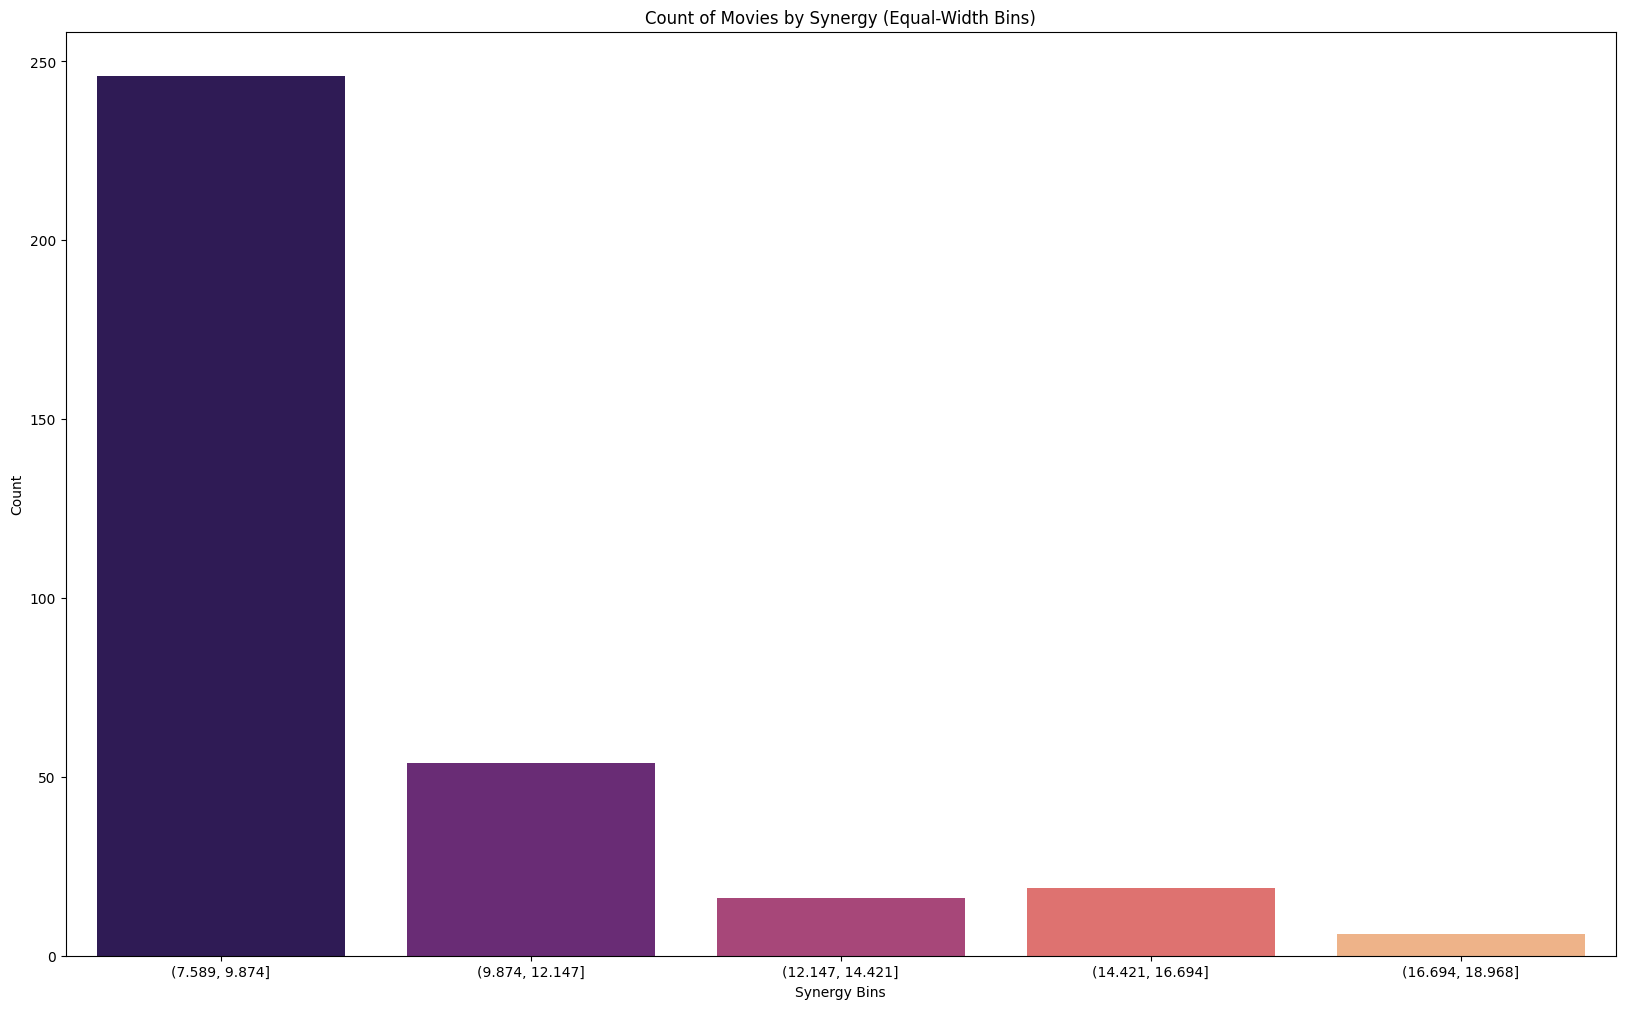

In [30]:
block_busters = df[df['Gross_inflation'] > 100000000]
block_busters['Synergy_Bins_Auto'] = pd.cut(block_busters['Duo_Synergy'], bins=5)

# Count and Plot
plt.figure(figsize=(20, 12))
sns.countplot(data=block_busters, x='Synergy_Bins_Auto', palette='magma')
plt.title('Count of Movies by Synergy (Equal-Width Bins)')
plt.xlabel('Synergy Bins')
plt.ylabel('Count')
plt.show()

In [31]:
# Compute a statistic that takes into account
genre_collumns = genre_final.columns

import pandas as pd

director_global_avg = df.groupby('Director')['IMDB_Rating'].mean()

genre_stats = []
for genre in genre_collumns:
    genre_avg = df[df[genre] == 1].groupby('Director')['IMDB_Rating'].mean()

    comfort_gap = genre_avg.sub(director_global_avg)

    comfort_gap.name = genre
    genre_stats.append(comfort_gap)

comfort_matrix = pd.concat(genre_stats, axis=1)

comfort_matrix = comfort_matrix.fillna(0)

def get_movie_comfort_score(row):
    director = row['Director']

    if director not in comfort_matrix.index:
        return 0.0

    movie_genres = [genre for genre in genre_collumns if row[genre] == 1]

    if not movie_genres:
        return 0.0

    gaps = comfort_matrix.loc[director, movie_genres]

    return gaps.max()

df['Director_Global_Score'] = df['Director'].map(director_global_avg)
df['Director_Comfort_Score'] = df.apply(get_movie_comfort_score, axis=1)

le = LabelEncoder()
df['Director'] = le.fit_transform(df['Director'].astype(str))



Meta_score Linear Model Performance (R^2 Score): 0.1153
Average Error (MAE): 7.8333 points

Linear Regression Coefficients (Impact on Meta_score):
IMDB_Rating               9.755746
Animation                 3.396566
Duo_Synergy               0.510599
Director_Comfort_Score   -0.239196
Director_Global_Score    -1.930769
Action                   -4.217694
dtype: float64


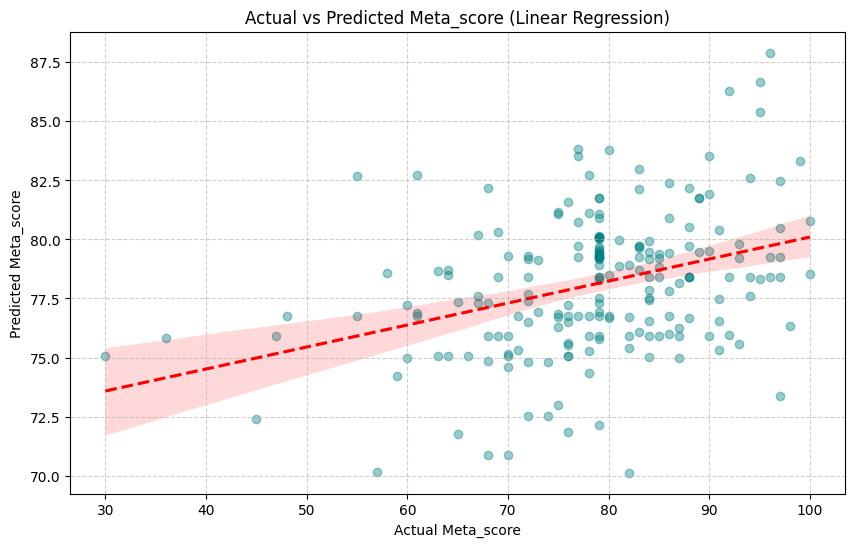

In [32]:

features = ['IMDB_Rating', 'Director_Global_Score', 'Duo_Synergy', 'Director_Comfort_Score', 'Animation', 'Action']
target = 'Meta_score'

model_df = df[features + [target]].dropna()

X = model_df[features]
y = model_df[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

lr_meta = LinearRegression()
lr_meta.fit(X_train, y_train)

y_pred = lr_meta.predict(X_test)

print(f"Meta_score Linear Model Performance (R^2 Score): {r2_score(y_test, y_pred):.4f}")
print(f"Average Error (MAE): {mean_absolute_error(y_test, y_pred):.4f} points")

coefficients = pd.Series(lr_meta.coef_, index=features).sort_values(ascending=False)
print("\nLinear Regression Coefficients (Impact on Meta_score):")
print(coefficients)

plt.figure(figsize=(10, 6))
sns.regplot(x=y_test, y=y_pred, scatter_kws={'alpha':0.4, 'color':'teal'}, line_kws={'color':'red', 'ls':'--'})
plt.xlabel('Actual Meta_score')
plt.ylabel('Predicted Meta_score')
plt.title('Actual vs Predicted Meta_score (Linear Regression)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

In [33]:
print (df.columns)

Index(['Poster_Link', 'Series_Title', 'Released_Year', 'Certificate',
       'Runtime', 'IMDB_Rating', 'Overview', 'Meta_score', 'Director', 'Star1',
       'Star2', 'Star3', 'Star4', 'No_of_Votes', 'Gross', 'Action',
       'Adventure', 'Animation', 'Biography', 'Comedy', 'Crime', 'Drama',
       'Family', 'Fantasy', 'History', 'Mystery', 'Romance', 'Sci-Fi',
       'Thriller', 'War', 'Other_Genre', 'scaled_votes', 'scaled_runtime',
       'Gross_log', 'Gross_inflation', 'Gross_log_inflation', 'Is_Outlier',
       'Duo_Synergy', 'Director_Global_Score', 'Director_Comfort_Score'],
      dtype='object')


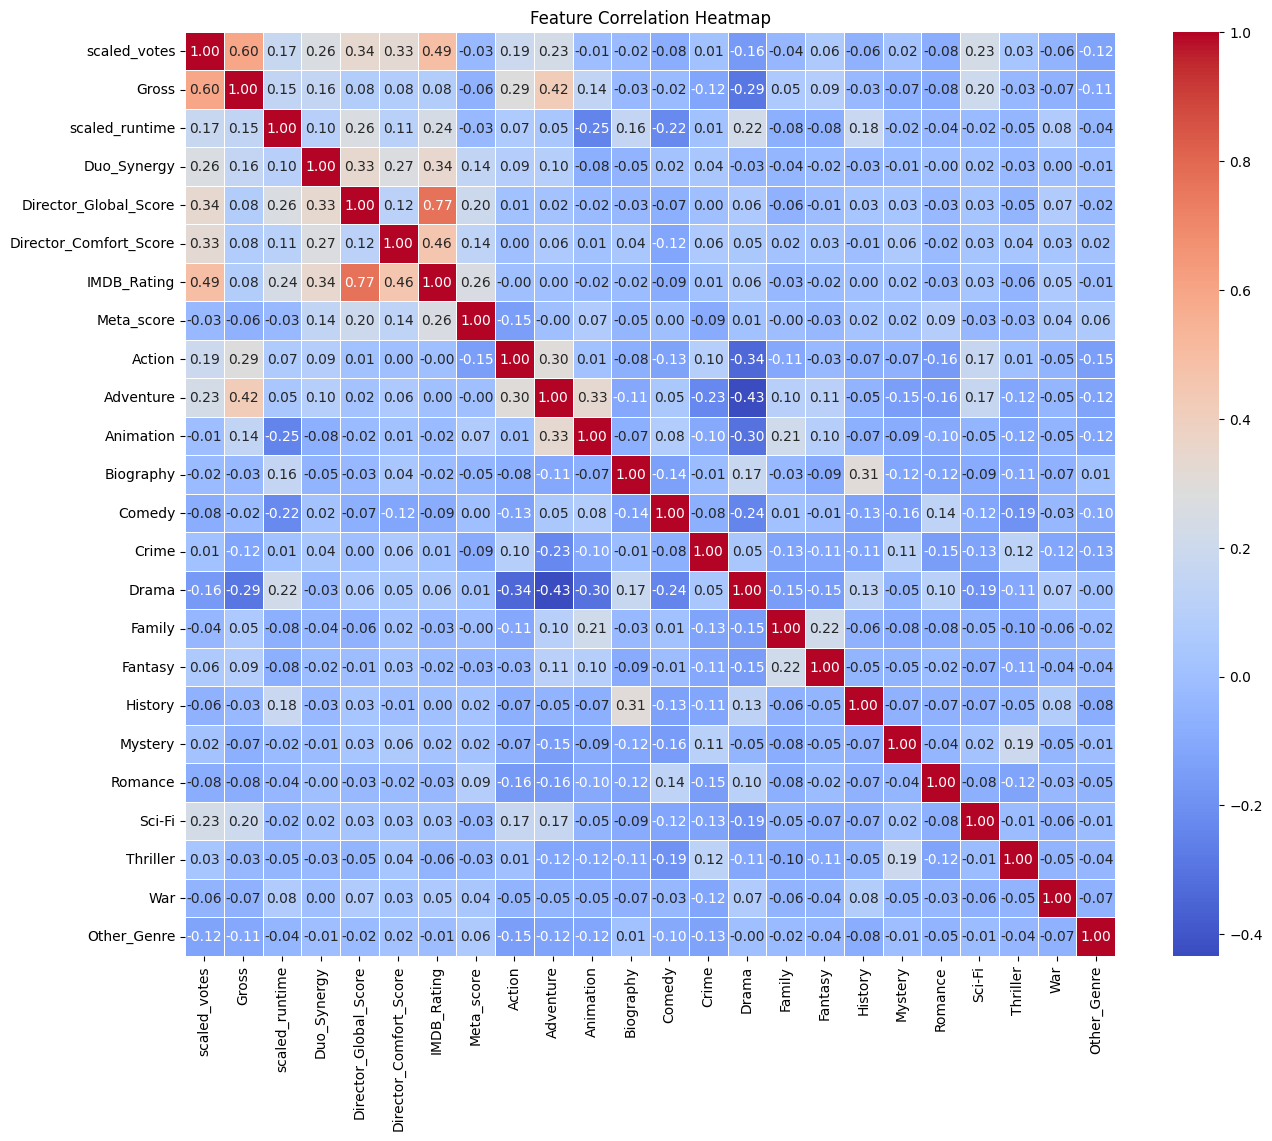

In [34]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Correctly combine the lists
# Using + creates a new list instead of returning 'None'
base_features = [
    'scaled_votes', 'Gross', 'scaled_runtime',
    'Duo_Synergy', 'Director_Global_Score', 'Director_Comfort_Score','IMDB_Rating','Meta_score'
]

# Combine base features with your genre column names
features = base_features + list(genre_collumns)

# 2. Calculate the correlation matrix
corr_matrix = df[features].corr()

# 3. Visualize it with a Heatmap
plt.figure(figsize=(15, 12)) # Made slightly larger to fit all genres
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Feature Correlation Heatmap")
plt.show()

/tmp/ipykernel_197/3577294845.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=plot, x='Decade', y='Runtime', palette='viridis')


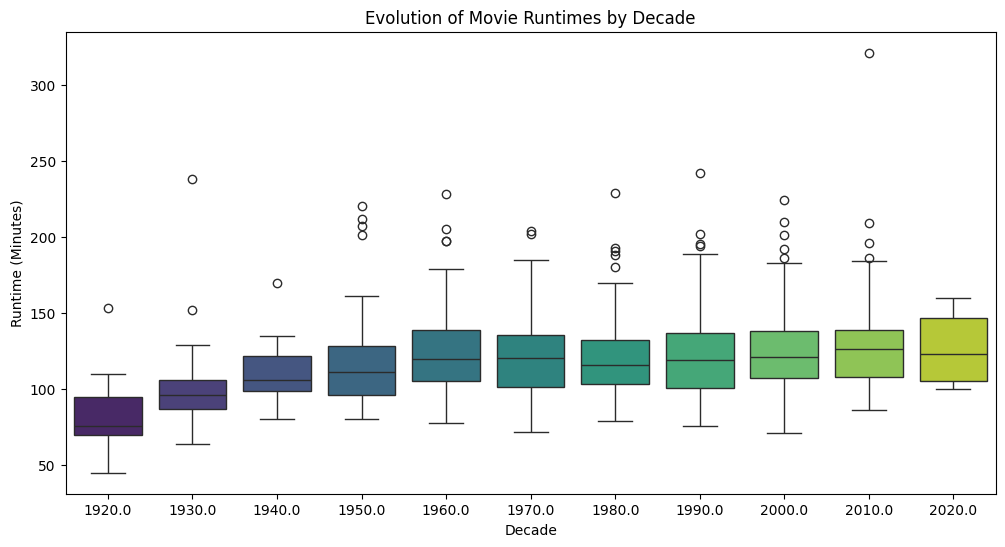

In [35]:
# Create a Decade column if you haven't yet

plot = df.copy()
plot['Decade'] = (df['Released_Year'] // 10) * 10

plt.figure(figsize=(12, 6))
sns.boxplot(data=plot, x='Decade', y='Runtime', palette='viridis')

plt.title('Evolution of Movie Runtimes by Decade')
plt.xlabel('Decade')
plt.ylabel('Runtime (Minutes)')
plt.show()

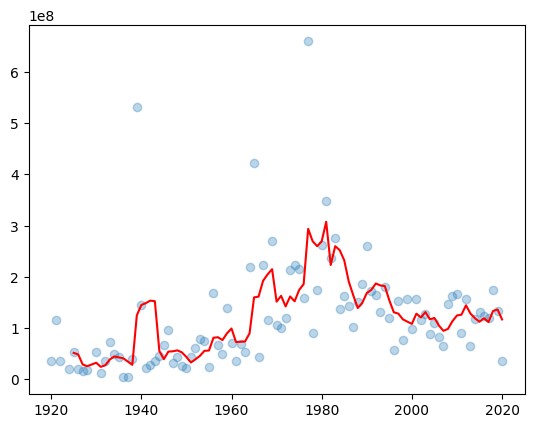

In [36]:
# Calculate yearly mean
yearly_revenue = df.groupby('Released_Year')['Gross_inflation'].mean()

smoothed_revenue = yearly_revenue.rolling(window=5).mean()

plt.plot(smoothed_revenue.index, smoothed_revenue.values, color='red', label='5-Year Trend')
plt.scatter(yearly_revenue.index, yearly_revenue.values, alpha=0.3) # Keep dots faint
plt.show()

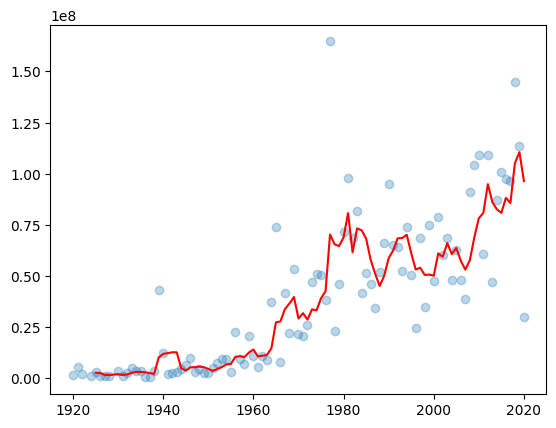

In [37]:
# Calculate yearly mean
yearly_revenue = df.groupby('Released_Year')['Gross'].mean()

smoothed_revenue = yearly_revenue.rolling(window=5).mean()

plt.plot(smoothed_revenue.index, smoothed_revenue.values, color='red', label='5-Year Trend')
plt.scatter(yearly_revenue.index, yearly_revenue.values, alpha=0.3) # Keep dots faint
plt.show()

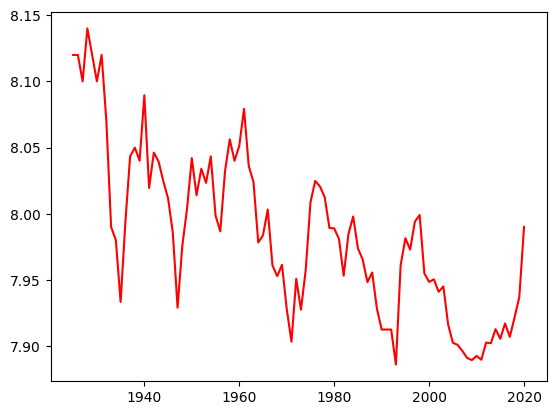

In [38]:
yearly_rating = df.groupby('Released_Year')['IMDB_Rating'].mean()
smoothed_rating = yearly_rating.rolling(window=5).mean()

plt.plot(smoothed_rating.index, smoothed_rating.values, color='red', label='5-Year Trend')
plt.show()

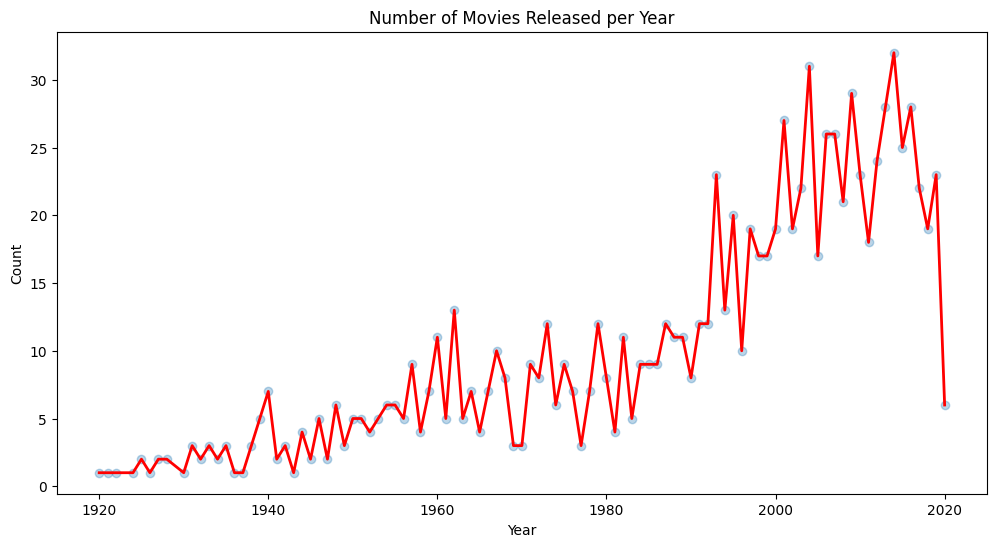

In [39]:
nr_movies = df.groupby('Released_Year').size()

x = nr_movies.index
y = nr_movies.values

plt.figure(figsize=(12,6))
plt.plot(x, y, color='red', linewidth=2)
plt.scatter(x, y, alpha=0.3)
plt.title("Number of Movies Released per Year")
plt.xlabel("Year")
plt.ylabel("Count")
plt.show()

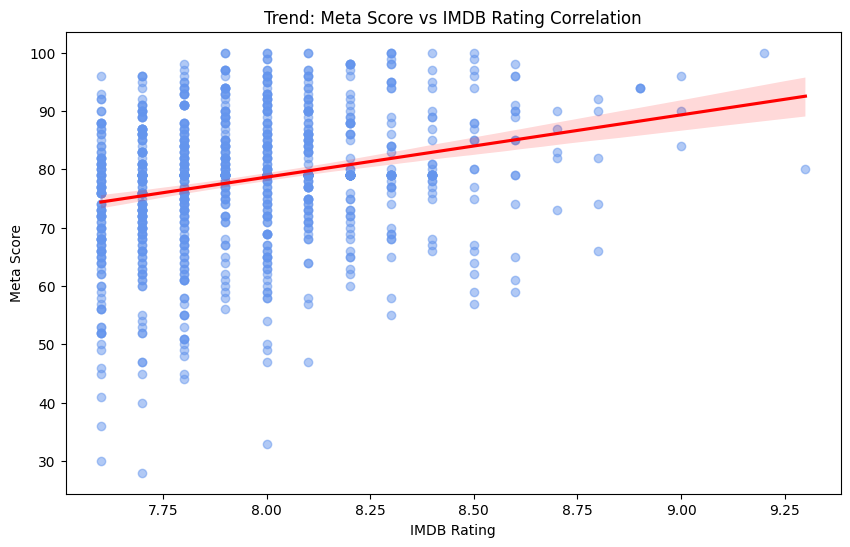

In [40]:


plt.figure(figsize=(10, 6))

sns.regplot(
    data=df,
    x='IMDB_Rating',
    y='Meta_score',
    scatter_kws={'alpha':0.5, 'color':'cornflowerblue'},
    line_kws={'color':'red'}
)

plt.title('Trend: Meta Score vs IMDB Rating Correlation')
plt.xlabel('IMDB Rating')
plt.ylabel('Meta Score')

plt.show()

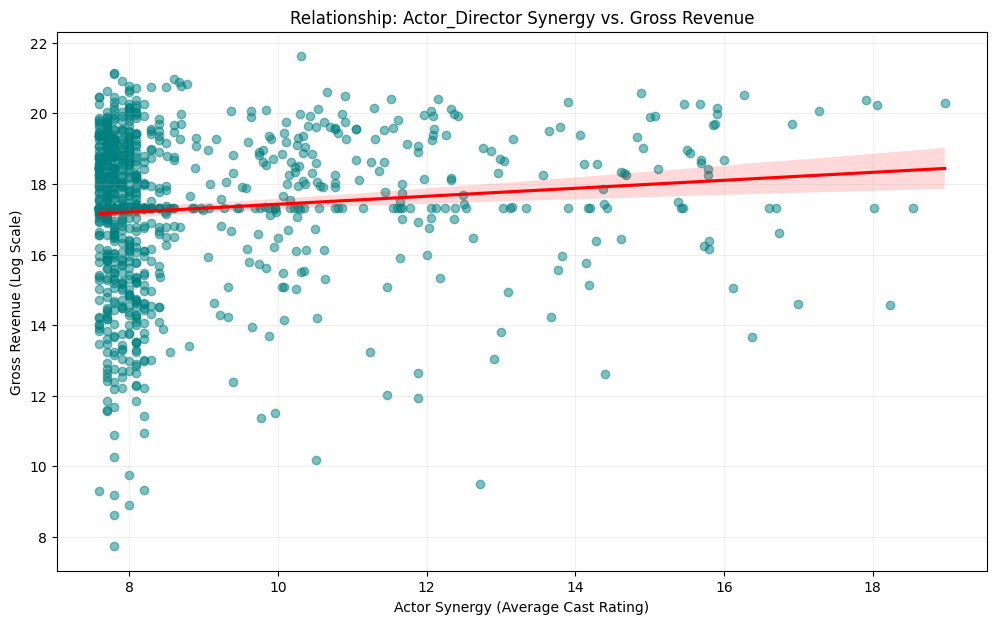

In [41]:
plt.figure(figsize=(12, 7))


plot = df.copy()

plot = plot[plot['Released_Year'] < 2019]
# We use a scatter plot with a regression line to see the trend
sns.regplot(
    data=plot,
    x='Duo_Synergy',
    y='Gross_log_inflation',
    scatter_kws={'alpha': 0.5, 'color': 'teal'},
    line_kws={'color': 'red'}
)


plt.title('Relationship: Actor_Director Synergy vs. Gross Revenue')
plt.xlabel('Actor Synergy (Average Cast Rating)')
plt.ylabel('Gross Revenue (Log Scale)')
plt.grid(True, which="both", ls="-", alpha=0.2)

plt.show()

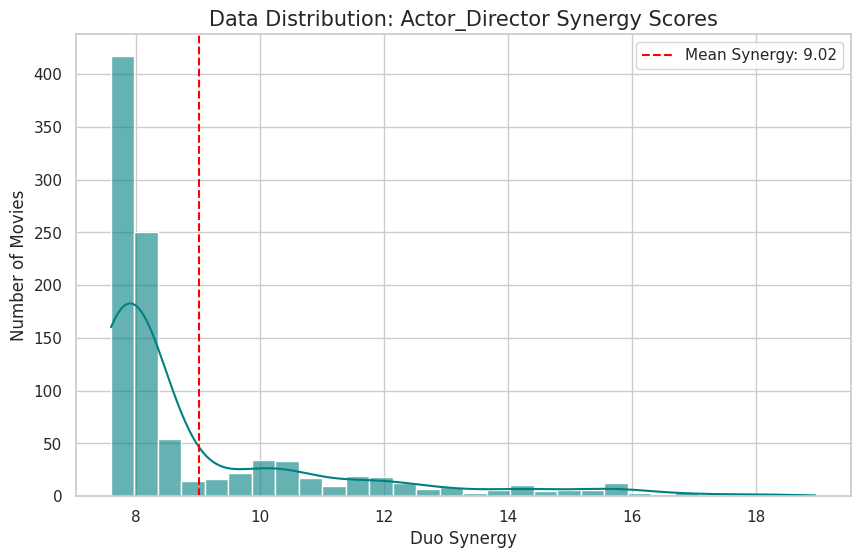

In [42]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))

sns.histplot(df['Duo_Synergy'], bins=30, kde=True, color='teal', alpha=0.6)

mean_val = df['Duo_Synergy'].mean()
plt.axvline(mean_val, color='red', linestyle='--', label=f'Mean Synergy: {mean_val:.2f}')

plt.title('Data Distribution: Actor_Director Synergy Scores', fontsize=15)
plt.xlabel('Duo Synergy', fontsize=12)
plt.ylabel('Number of Movies', fontsize=12)
plt.legend()

plt.show()

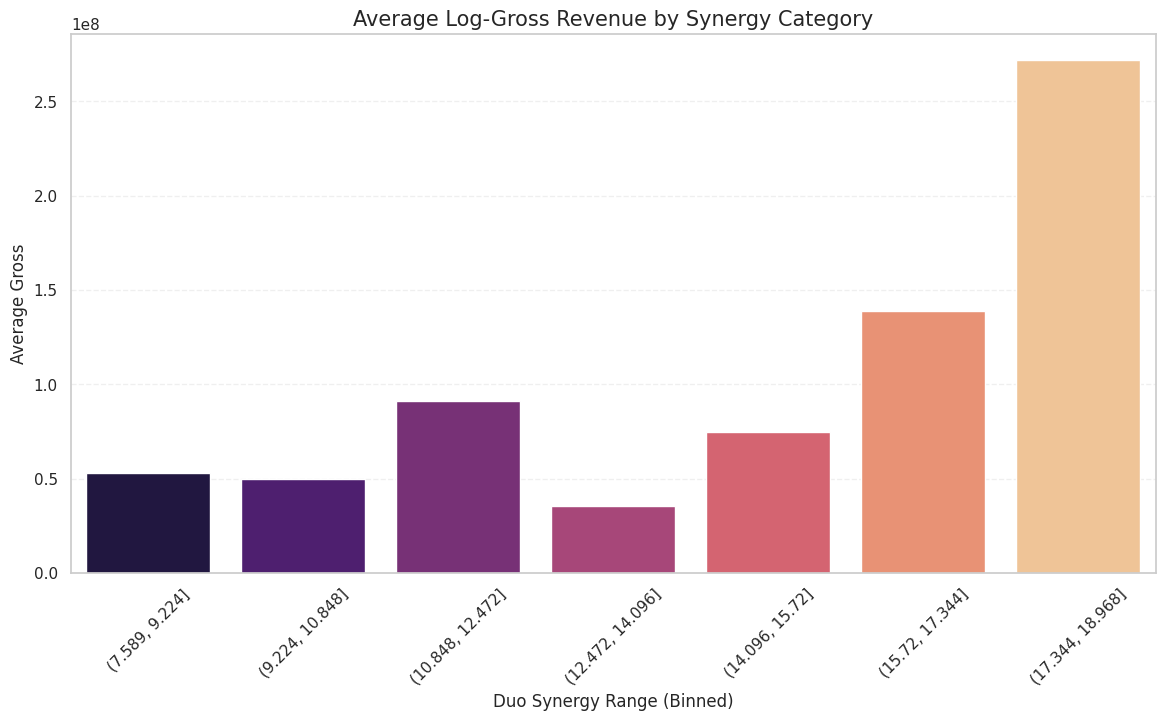

In [43]:
plot = df.copy()
plot['Synergy_Bin'] = pd.cut(df['Duo_Synergy'], bins=7)

log_bin_analysis = plot.groupby('Synergy_Bin', observed=True)['Gross'].mean().reset_index()

log_bin_analysis['Synergy_Bin'] = log_bin_analysis['Synergy_Bin'].astype(str)

plt.figure(figsize=(14, 7))

sns.barplot(
    data=log_bin_analysis,
    x='Synergy_Bin',
    y='Gross',
    palette='magma',
    hue='Synergy_Bin',
    legend=False
)

plt.title('Average Log-Gross Revenue by Synergy Category', fontsize=15)
plt.xlabel('Duo Synergy Range (Binned)', fontsize=12)
plt.ylabel('Average Gross', fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.3)

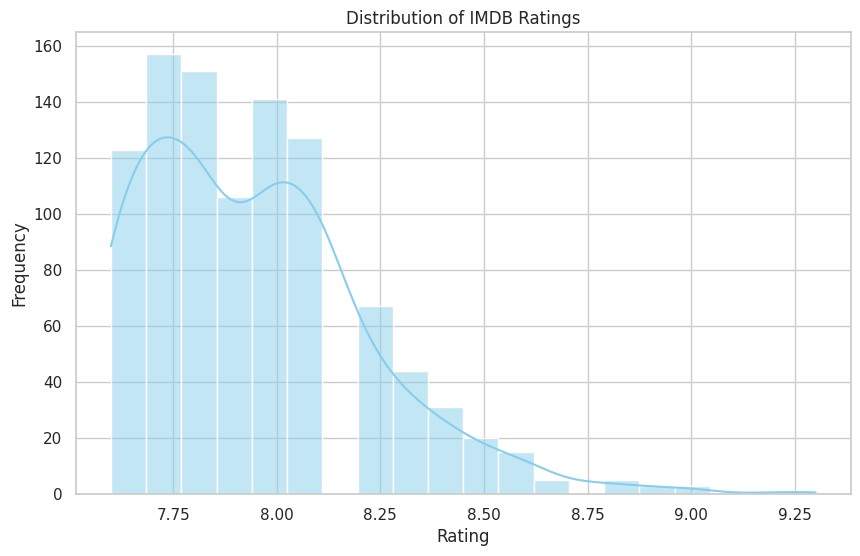

In [44]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

# 'kde=True' adds a smooth line over the bars to show the overall shape
sns.histplot(df['IMDB_Rating'], bins=20, kde=True, color='skyblue')

plt.title('Distribution of IMDB Ratings')
plt.xlabel('Rating')
plt.ylabel('Frequency')
plt.show()

In [45]:
lowest_meta_Scores = df[df['Meta_score'] < 50][['Meta_score','Series_Title']].sort_values(by='Meta_score', ascending=False)
highest_meta_Scores = df[df['Meta_score'] > 90]['Series_Title'].sort_values()
print(lowest_meta_Scores.head(50))
print(highest_meta_Scores.head(50))


boh = df.loc[df['Series_Title'] == 'Tropa de Elite', 'Meta_score']
print(boh)


     Meta_score                    Series_Title
342        49.0               Bohemian Rhapsody
960        49.0                        Sleepers
597        49.0             La migliore offerta
644        48.0             Remember the Titans
272        47.0            Pink Floyd: The Wall
811        47.0                     Primal Fear
397        47.0                  Bound by Honor
782        47.0                     Man on Fire
932        46.0                             Saw
677        45.0                        Predator
760        45.0                         Flipped
935        45.0                  Jeux d'enfants
648        44.0             The Boondock Saints
957        41.0  Fear and Loathing in Las Vegas
735        40.0                     Kai po che!
917        36.0                    Seven Pounds
356        33.0                  Tropa de Elite
942        30.0            The Butterfly Effect
788        28.0                        I Am Sam
4                                       

In [55]:



df_recommender = df.copy()
df_recommender.set_index('Series_Title', inplace=True)

print(df.columns)
columns_to_drop = ['Poster_Link', 'Overview', 'Star1', 'Star2', 'Star3', 'Star4',
                   'Gross', 'Gross_inflation', 'Certificate','IMDB_Rating','Gross_log','Meta_Score','No_of_Votes','Runtime','Meta_Score']
df_recommender.drop(columns=columns_to_drop, inplace=True, errors='ignore')
print(df_recommender.columns)

scaler = StandardScaler()
math_table = df_recommender.fillna(0)
scaled_math_array = scaler.fit_transform(math_table)

similarity_matrix = cosine_similarity(scaled_math_array)
pca = PCA(n_components=10)
pca_math_array = pca.fit_transform(scaled_math_array)

explained_var = sum(pca.explained_variance_ratio_) * 100
print(f"PCA reduced the data but kept {explained_var:.1f}% of the original variance.\n")
similarity_df = pd.DataFrame(similarity_matrix,
                             index=math_table.index,
                             columns=math_table.index)

def recommend_movies(movie_title, top_n=5):
    if movie_title not in similarity_df.index:
        return "Movie not found in dataset"

    scores = similarity_df[movie_title].sort_values(ascending=False)

    top_matches = scores.iloc[1:top_n+1]

    print(f"Because you liked '{movie_title}', you should watch:\n")
    for title, score in top_matches.items():
        print(f"- {title} (Similarity Match: {score*100:.1f}%)")


name = "Brazil"
recommend_movies(name, top_n=20)

Index(['Poster_Link', 'Series_Title', 'Released_Year', 'Certificate',
       'Runtime', 'IMDB_Rating', 'Overview', 'Meta_score', 'Director', 'Star1',
       'Star2', 'Star3', 'Star4', 'No_of_Votes', 'Gross', 'Action',
       'Adventure', 'Animation', 'Biography', 'Comedy', 'Crime', 'Drama',
       'Family', 'Fantasy', 'History', 'Mystery', 'Romance', 'Sci-Fi',
       'Thriller', 'War', 'Other_Genre', 'scaled_votes', 'scaled_runtime',
       'Gross_log', 'Gross_inflation', 'Gross_log_inflation', 'Is_Outlier',
       'Duo_Synergy', 'Director_Global_Score', 'Director_Comfort_Score'],
      dtype='object')
Index(['Released_Year', 'Meta_score', 'Director', 'Action', 'Adventure',
       'Animation', 'Biography', 'Comedy', 'Crime', 'Drama', 'Family',
       'Fantasy', 'History', 'Mystery', 'Romance', 'Sci-Fi', 'Thriller', 'War',
       'Other_Genre', 'scaled_votes', 'scaled_runtime', 'Gross_log_inflation',
       'Is_Outlier', 'Duo_Synergy', 'Director_Global_Score',
       'Director_Comfort_S

In [69]:
import scipy.linalg as la

def softmax_rows(matrix, T=1.0):
    # We divide the similarity scores by T
    shift_matrix = (matrix - np.max(matrix, axis=1, keepdims=True)) / T

    exps = np.exp(shift_matrix)

    return exps / np.sum(exps, axis=1, keepdims=True)


T_value = 0.7

A = similarity_matrix.copy()
np.fill_diagonal(A, -np.inf)

A_markov = softmax_rows(A, T=T_value)



values, vectors = la.eig(A_markov, left=True, right=False)

idx = np.argmin(np.abs(values - 1.0))

pi_exact = np.real(vectors[:, idx])

pi_exact = pi_exact / pi_exact.sum()


def get_markov_recommendation(movie_title, alpha=0.8):

    if movie_title not in math_table.index:
        return "Movie not found"

    movie_idx = math_table.index.get_loc(movie_title)

    immediate_matches = A_markov[movie_idx]

    final_score = (alpha * immediate_matches) + ((1 - alpha) * pi_exact)

    recommendations = pd.Series(final_score, index=math_table.index).sort_values(ascending=False)

    return recommendations.head(5)

print(get_markov_recommendation("A Clockwork Orange"))

Series_Title
Close Encounters of the Third Kind    0.002390
Brazil                                0.002390
2001: A Space Odyssey                 0.002169
Metropolis                            0.002116
The Day the Earth Stood Still         0.002106
dtype: float64
